In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
summary = pd.read_csv("summary.csv")
summary

,temperature,n_inscope_answers,effectiveness,faithfulness,correctness,n_ood_answers,ood_refusal_rate
0,0,44,0.886,0.886,0.864,6,0.833
1,0.2,132,0.886,0.879,0.864,18,0.833
2,0.5,132,0.909,0.917,0.886,18,0.889
3,0.7,132,0.894,0.894,0.879,18,0.833
4,1.0,132,0.902,0.917,0.886,18,0.833
5,ALL,572,0.897,0.900,0.878,78,0.846


In [5]:
configuration = pd.read_csv("~/CSDS-WIL-Group-17-RAG/testing/generator_testing/configuration.csv")
configuration

,question_id,query,precision@k,recall@k,hit-rate@k,mrr@k,ndcg@k,f1@k,mean_total_eval_metrics_score@k,k,temperature,search_type,expected_answer,expected_sources,actual_sources_in_order
0,c1i1,Can my solar battery be created within 24 mont...,1.0,0.333333,1.0,1.0,1.0,0.5,0.805556,1,0.0,similarity,"No, the maximum is 12 months","[17, 43, 22]",['22']
1,c1i1,Can my solar battery be created within 24 mont...,1.0,0.333333,1.0,1.0,1.0,0.5,0.805556,1,0.0,mmr,"No, the maximum is 12 months","[17, 43, 22]",['22']
2,c1i1,Can my solar battery be created within 24 mont...,1.0,0.333333,1.0,1.0,1.0,0.5,0.805556,1,0.2,similarity,"No, the maximum is 12 months","[17, 43, 22]",['22']
3,c1i1,Can my solar battery be created within 24 mont...,1.0,0.333333,1.0,1.0,1.0,0.5,0.805556,1,0.2,mmr,"No, the maximum is 12 months","[17, 43, 22]",['22']
4,c1i1,Can my solar battery be created within 24 mont...,1.0,0.333333,1.0,1.0,1.0,0.5,0.805556,1,0.4,similarity,"No, the maximum is 12 months","[17, 43, 22]",['22']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,c8k3,Under what circumstances can multiple installe...,1.0,1.000000,1.0,1.0,1.0,1.0,1.000000,1,0.6,mmr,There can be multiple installers on an install...,[32],['32']
507,c8k3,Under what circumstances can multiple installe...,1.0,1.000000,1.0,1.0,1.0,1.0,1.000000,1,0.8,similarity,There can be multiple installers on an install...,[32],['32']
508,c8k3,Under what circumstances can multiple installe...,1.0,1.000000,1.0,1.0,1.0,1.0,1.000000,1,0.8,mmr,There can be multiple installers on an install...,[32],['32']
509,c8k3,Under what circumstances can multiple installe...,1.0,1.000000,1.0,1.0,1.0,1.0,1.000000,1,1.0,similarity,There can be multiple installers on an install...,[32],['32']


In [47]:
configuration = configuration[["question_id", "k", "search_type"]].drop_duplicates()
configuration["question_type"] = configuration["question_id"].str[2] == "i"

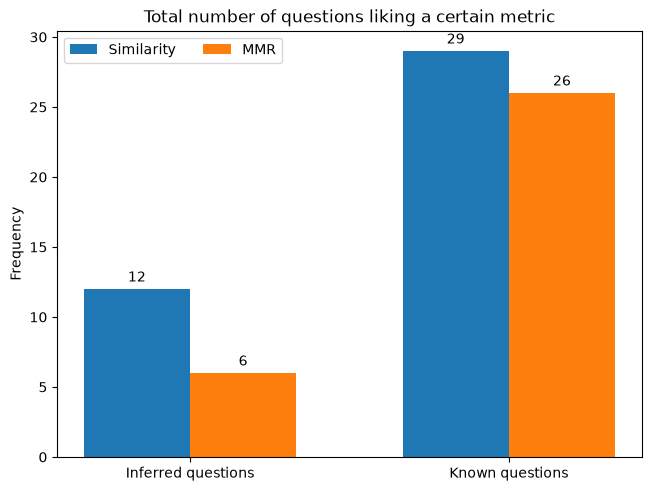

In [180]:
needed_information = configuration[["question_id", "question_type", "k", "search_type"]]
inferred = needed_information[needed_information["question_type"]]
known = needed_information[~needed_information["question_type"]]
similarity = 0
mmr = 0
similarity_1 = 0
mmr_1 = 0
for value in inferred["search_type"]:
    if value == "similarity":
        similarity += 1
    else:
        mmr += 1
for value in known["search_type"]:
    if value == "similarity":
        similarity_1 += 1
    else:
        mmr_1 += 1
question_type = ["Inferred questions", "Known questions"]
dict_for_graphing = {"Similarity":(similarity, similarity_1),
                     "MMR":(mmr, mmr_1)}

fig, ax = plt.subplots(layout='constrained')

res = ax.grouped_bar(dict_for_graphing, tick_labels=question_type, group_spacing=1)
for container in res.bar_containers:
    ax.bar_label(container, padding=3)
ax.set_ylabel("Frequency")
ax.set_title("Total number of questions liking a certain metric")
ax.legend(loc='upper left', ncols=3);

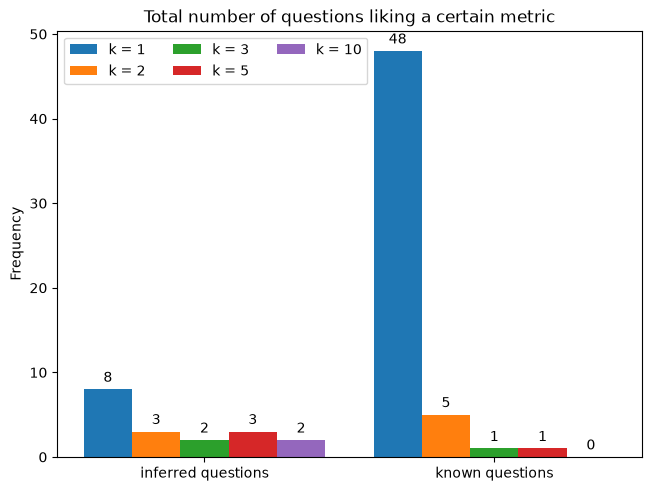

In [181]:
step_1 = needed_information[needed_information["question_type"]].groupby("k").count()["question_id"]
step_2 = needed_information[~needed_information["question_type"]].groupby("k").count()["question_id"]
keys = ["k = 1","k = 2","k = 3","k = 5","k = 10"]
k_for_graphing = {}
count = 0
for i in step_1:
    k_for_graphing[keys[count]] = [i]
    count += 1
count = 0
for j in step_2:
    k_for_graphing[keys[count]].append(j)
    count += 1
else:
    k_for_graphing["k = 10"].append(0)
question_type = ["inferred questions", "known questions"]
fig, ax = plt.subplots(layout='constrained')

res = ax.grouped_bar(k_for_graphing, tick_labels=question_type, group_spacing=1)
for container in res.bar_containers:
    ax.bar_label(container, padding=3)
ax.legend(loc='upper left', ncols=3)
ax.set_ylabel("Frequency")
ax.set_title("Total number of questions liking a certain metric");

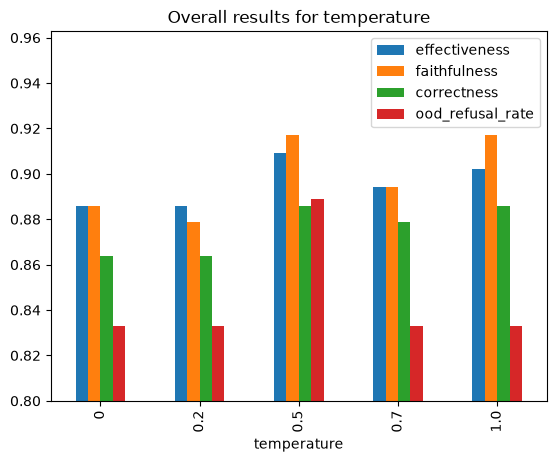

In [232]:
important_values = summary[["temperature", "effectiveness", "faithfulness", "correctness", "ood_refusal_rate"]].iloc[:5]
plot = important_values.plot.bar(x = "temperature")
plot.set_ylim(0.8)
plot.set_title("Overall results for temperature");